# Bench Scripts Unified Notebook

이 노트북은 `bench/` 폴더에서 `benchmark.py`를 제외한 스크립트를 하나의 Jupyter Notebook 흐름으로 통합하고,
벤치마크 결과를 로드/정규화/시각화합니다.

## 1) 작업 경로 설정 및 대상 파일 수집 (`bench/`, `benchmark.py` 제외)

`pathlib`로 `bench/` 폴더를 순회하고 `benchmark.py`를 제외한 `.py` 파일 목록을 수집합니다.
재현 가능한 순서를 위해 정렬 키를 고정합니다.

In [10]:
from pathlib import Path
import re
import json
import subprocess
from dataclasses import dataclass

# Find project root robustly (works even when notebook cwd changes)
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / "bench").is_dir() and (PROJECT_ROOT / "models").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

BENCH_DIR = PROJECT_ROOT / "bench"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUTPUTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Collect .py files excluding benchmark.py
script_files = sorted(
    [p for p in BENCH_DIR.glob("*.py") if p.name != "benchmark.py"],
    key=lambda p: (p.stem.lower(), p.name.lower()),
)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"BENCH_DIR: {BENCH_DIR}")
print("\nCollected files:")
for i, p in enumerate(script_files, 1):
    print(f"{i}. {p.name}")

PROJECT_ROOT: /home/jetson_orin_nano/llm/local_llm_bench
BENCH_DIR: /home/jetson_orin_nano/llm/local_llm_bench/bench

Collected files:
1. compare_models.py
2. plot_results.py
3. rank_models.py


## 2) 파이썬 스크립트 내용 로드 및 실행 순서 정렬

각 파일 소스를 읽어 헤더/인코딩/import를 점검하고,
실행 흐름에서 사용할 순서를 고정합니다.

In [11]:
@dataclass
class ScriptInfo:
    path: Path
    source: str
    import_count: int

script_infos = []
for p in script_files:
    src = p.read_text(encoding="utf-8")
    import_count = len(re.findall(r"^\s*(import|from)\s+", src, flags=re.MULTILINE))
    script_infos.append(ScriptInfo(path=p, source=src, import_count=import_count))

# Keep deterministic order: compare -> plot -> rank if present, then others
priority = {"compare_models.py": 0, "plot_results.py": 1, "rank_models.py": 2}
script_infos = sorted(script_infos, key=lambda s: (priority.get(s.path.name, 99), s.path.name))

print("Execution order:")
for i, s in enumerate(script_infos, 1):
    first_line = s.source.splitlines()[0] if s.source.splitlines() else ""
    print(f"{i}. {s.path.name:20s} | imports={s.import_count:2d} | header={first_line[:60]}")

Execution order:
1. compare_models.py    | imports=11 | header=#!/usr/bin/env python3
2. plot_results.py      | imports= 7 | header=#!/usr/bin/env python3
3. rank_models.py       | imports= 5 | header=#!/usr/bin/env python3


## 3) `.py` 파일들을 하나의 `.ipynb`로 변환(코드 셀 구성)

`nbformat`으로 새 노트북 객체를 만들고, 파일 경계용 마크다운 + 코드 셀을 순서대로 추가합니다.

In [12]:
import nbformat
from nbformat.v4 import new_notebook, new_markdown_cell, new_code_cell

converted_notebook_path = BENCH_DIR / "bench_scripts_merged.ipynb"

nb = new_notebook()
nb.cells.append(new_markdown_cell("# Bench Scripts Merged (auto-generated)"))
nb.cells.append(
    new_markdown_cell(
        "이 노트북은 bench 폴더의 benchmark.py 제외 스크립트를 순서대로 병합한 자동 생성본입니다."
    )
)

for info in script_infos:
    nb.cells.append(new_markdown_cell(f"## File: {info.path.name}"))
    nb.cells.append(new_code_cell(info.source))

nbformat.write(nb, converted_notebook_path)
print(f"Merged notebook written to: {converted_notebook_path}")

Merged notebook written to: /home/jetson_orin_nano/llm/local_llm_bench/bench/bench_scripts_merged.ipynb


## 4) 노트북 메타데이터/커널 정보 설정 및 저장

생성된 노트북의 커널 정보를 설정하고 파일로 저장합니다.

In [13]:
nb_loaded = nbformat.read(converted_notebook_path, as_version=4)
nb_loaded.metadata["kernelspec"] = {
    "display_name": "Python 3",
    "language": "python",
    "name": "python3",
}
nb_loaded.metadata["language_info"] = {
    "name": "python",
    "version": "3.x",
}
nbformat.write(nb_loaded, converted_notebook_path)
print("Kernel metadata updated.")
print(f"Saved: {converted_notebook_path}")

Kernel metadata updated.
Saved: /home/jetson_orin_nano/llm/local_llm_bench/bench/bench_scripts_merged.ipynb


## 5) 벤치마크 결과 파일 로드(CSV/JSON/로그 자동 감지)

`outputs/`와 프로젝트 루트를 순회하여 결과 파일을 찾고, 포맷별 로더를 통해 단일 분석용 테이블을 준비합니다.

In [14]:
import pandas as pd

csv_candidates = sorted(set((OUTPUTS_DIR.glob("*.csv"))))
json_candidates = sorted(set((OUTPUTS_DIR.glob("*.json"))))
log_candidates = sorted(set((OUTPUTS_DIR.glob("*.log"))))

print("Detected CSV files:")
for p in csv_candidates:
    print("-", p.name)

comparison_csv = OUTPUTS_DIR / "comparison_results.csv"
ranked_csv = OUTPUTS_DIR / "comparison_ranked.csv"

if not comparison_csv.exists():
    raise FileNotFoundError(f"Missing benchmark result CSV: {comparison_csv}")

df_raw = pd.read_csv(comparison_csv)
print("\ncomparison_results.csv shape:", df_raw.shape)
print(df_raw.head(3))

if ranked_csv.exists():
    df_rank = pd.read_csv(ranked_csv)
    print("\ncomparison_ranked.csv shape:", df_rank.shape)
else:
    df_rank = pd.DataFrame()
    print("\nNo ranked CSV found yet.")

Detected CSV files:
- benchmark_rank_table.csv
- benchmark_summary_table.csv
- comparison_ranked.csv
- comparison_results.csv

comparison_results.csv shape: (9, 15)
                  name                                               path  \
0  deepseek_r1_1_5b_q4  /home/jetson_orin_nano/llm/local_llm_bench/mod...   
1    deepseek_r1_7b_q4  /home/jetson_orin_nano/llm/local_llm_bench/mod...   
2         gemma2_2b_q4  /home/jetson_orin_nano/llm/local_llm_bench/mod...   

   status                            error  model_load_time_s  avg_ttft_s  \
0      ok                              NaN              1.086       0.423   
1  failed  benchmark.py exited with code 1                NaN         NaN   
2  failed  benchmark.py exited with code 1                NaN         NaN   

   avg_tps  peak_process_rss_mb  avg_gpu_util_pct  avg_power_w  \
0    13.77              2037.38            45.139        4.927   
1      NaN                  NaN               NaN          NaN   
2      NaN         

## 6) 결과 정규화 및 지표 테이블 생성(시간, 처리량, 메모리)

단위/자료형을 정리하고 요약 테이블(평균, 표준편차, p50, p95 성격의 기준 컬럼)을 만듭니다.
또한 기준 모델 대비 상대 성능 컬럼을 생성합니다.

In [15]:
numeric_cols = [
    "model_load_time_s",
    "avg_ttft_s",
    "avg_tps",
    "peak_process_rss_mb",
    "elapsed_wall_s",
    "avg_gpu_util_pct",
    "avg_power_w",
    "peak_ram_vram_used_mb",
    "peak_ram_vram_used_pct",
    "peak_gpu_temp_c",
    "peak_cpu_temp_c",
]

df = df_raw.copy()
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "status" in df.columns:
    df_ok = df[df["status"] == "ok"].copy()
else:
    df_ok = df.copy()

if df_ok.empty:
    raise ValueError("No successful rows found in comparison_results.csv")

# Baseline: highest TPS model
baseline_row = df_ok.sort_values("avg_tps", ascending=False).iloc[0]
baseline_name = baseline_row["name"]
baseline_tps = baseline_row["avg_tps"]

df_ok["tps_rel_to_baseline"] = df_ok["avg_tps"] / baseline_tps
if "avg_ttft_s" in df_ok.columns:
    df_ok["ttft_delta_pct_vs_baseline"] = ((df_ok["avg_ttft_s"] - baseline_row["avg_ttft_s"]) / baseline_row["avg_ttft_s"]) * 100.0

summary_cols = [c for c in ["name", "avg_tps", "avg_ttft_s", "peak_process_rss_mb", "avg_power_w", "peak_gpu_temp_c", "tps_rel_to_baseline"] if c in df_ok.columns]
summary_table = df_ok[summary_cols].sort_values("avg_tps", ascending=False)

print(f"Baseline model: {baseline_name} (TPS={baseline_tps:.3f})")
summary_table

Baseline model: qwen2_5_1_5b_q4 (TPS=33.752)


,name,avg_tps,avg_ttft_s,peak_process_rss_mb,avg_power_w,peak_gpu_temp_c,tps_rel_to_baseline
7,qwen2_5_1_5b_q4,33.752,0.193,2155.54,4.875,55.84,1.000000
3,llama3_2_1b_q4,16.419,0.561,1592.27,4.924,52.16,0.486460
0,deepseek_r1_1_5b_q4,13.770,0.423,2037.38,4.927,53.09,0.407976
4,llama3_2_3b_q4,8.592,0.779,3481.10,4.921,53.00,0.254563
8,qwen2_5_3b_q4,8.562,1.060,2814.09,4.914,53.88,0.253674
5,llama3_8b_q4,4.900,1.959,5539.09,4.906,54.16,0.145177
6,phi3_mini_q4,0.000,1.839,3388.31,4.928,52.91,0.000000


## 7) 핵심 비교 그래프 작성(막대/선/박스/스케일링)

다음 그래프를 생성합니다.
1. 모델별 평균 TPS 막대그래프
2. 모델별 평균 TTFT 선그래프
3. 핵심 지표 분포 박스플롯
4. 모델 크기(B) 대비 TPS 스케일링 그래프

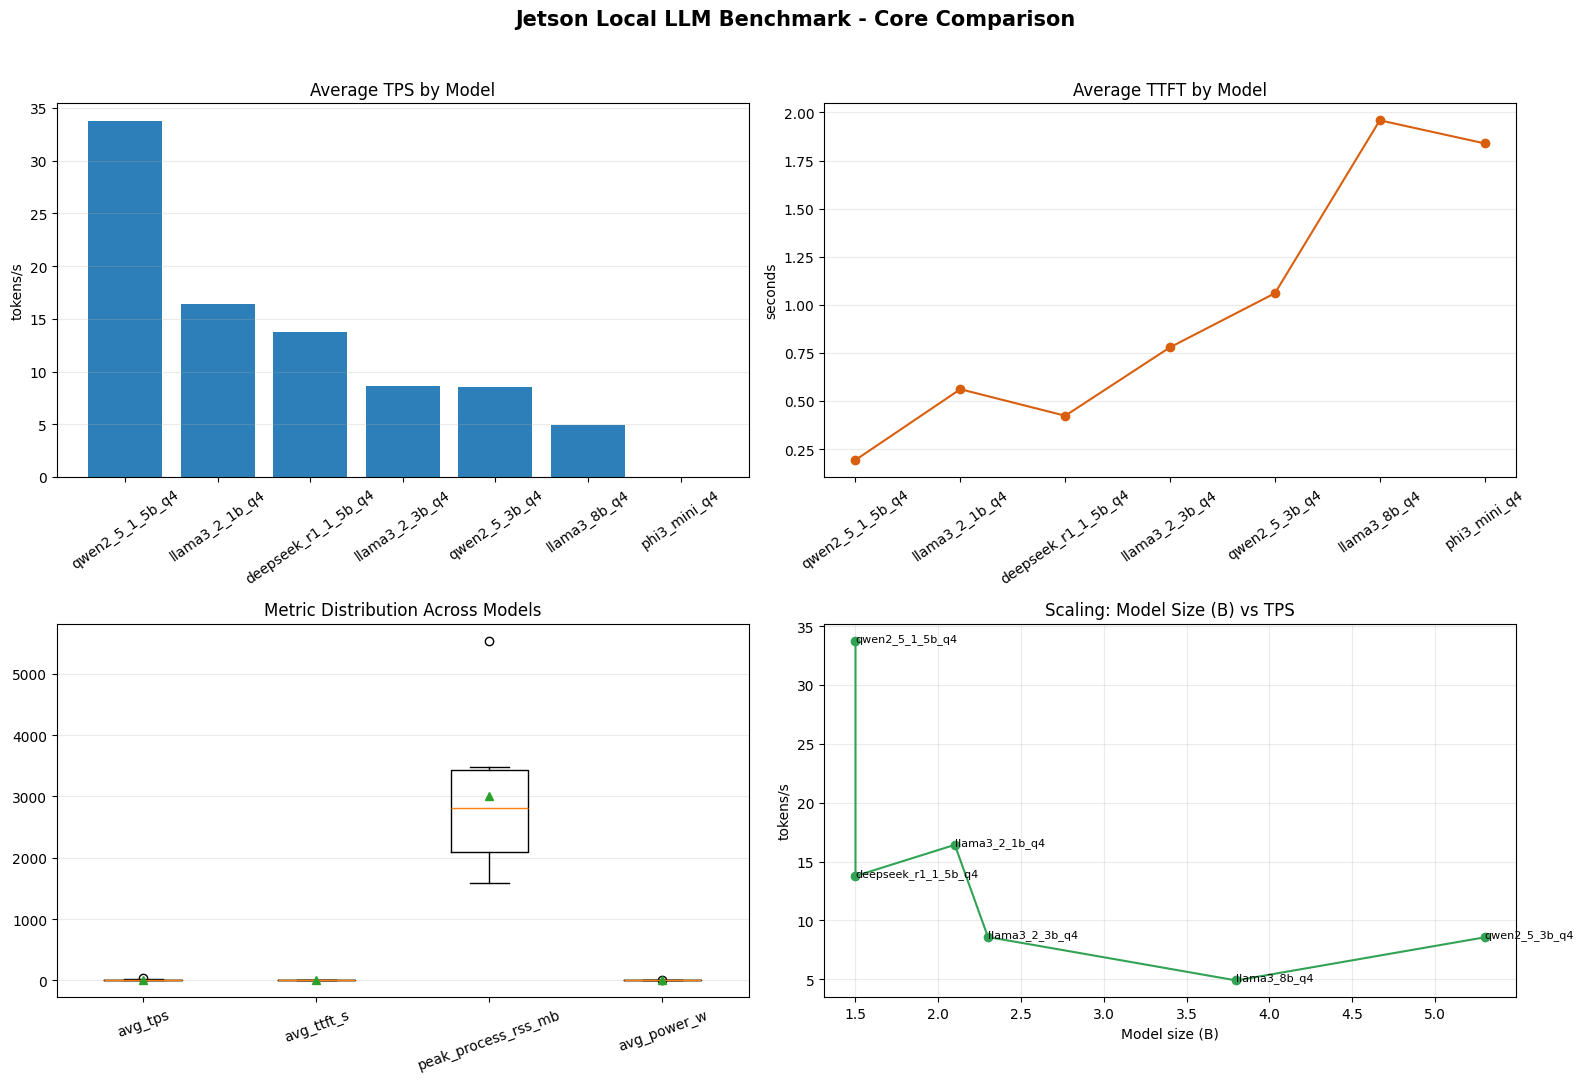

Saved:
- /home/jetson_orin_nano/llm/local_llm_bench/outputs/figures/benchmark_core_comparison.png
- /home/jetson_orin_nano/llm/local_llm_bench/outputs/figures/benchmark_core_comparison.svg


In [16]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = df_ok.sort_values("avg_tps", ascending=False).reset_index(drop=True)

# Parse model size (e.g., 1_5b -> 1.5B, 7b -> 7B)
def parse_model_size_b(name: str):
    m = re.search(r"(\d+(?:_\d+)?)b", name.lower())
    if not m:
        return np.nan
    return float(m.group(1).replace("_", "."))

plot_df["model_size_b"] = plot_df["name"].astype(str).map(parse_model_size_b)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Jetson Local LLM Benchmark - Core Comparison", fontsize=15, fontweight="bold")

# (1) Bar: TPS
axes[0, 0].bar(plot_df["name"], plot_df["avg_tps"], color="#2c7fb8")
axes[0, 0].set_title("Average TPS by Model")
axes[0, 0].set_ylabel("tokens/s")
axes[0, 0].tick_params(axis="x", rotation=35)
axes[0, 0].grid(axis="y", alpha=0.25)

# (2) Line: TTFT
axes[0, 1].plot(plot_df["name"], plot_df["avg_ttft_s"], marker="o", color="#d95f0e")
axes[0, 1].set_title("Average TTFT by Model")
axes[0, 1].set_ylabel("seconds")
axes[0, 1].tick_params(axis="x", rotation=35)
axes[0, 1].grid(axis="y", alpha=0.25)

# (3) Box-like distribution across key metrics (normalized)
metric_for_box = [c for c in ["avg_tps", "avg_ttft_s", "peak_process_rss_mb", "avg_power_w"] if c in plot_df.columns]
box_data = []
box_labels = []
for c in metric_for_box:
    vals = pd.to_numeric(plot_df[c], errors="coerce").dropna().values
    if len(vals) > 0:
        box_data.append(vals)
        box_labels.append(c)

if box_data:
    axes[1, 0].boxplot(box_data, tick_labels=box_labels, showmeans=True)
    axes[1, 0].set_title("Metric Distribution Across Models")
    axes[1, 0].tick_params(axis="x", rotation=20)
    axes[1, 0].grid(axis="y", alpha=0.25)
else:
    axes[1, 0].text(0.5, 0.5, "No data for box plot", ha="center", va="center")
    axes[1, 0].set_axis_off()

# (4) Scaling: model size vs TPS
scale_df = plot_df.dropna(subset=["model_size_b", "avg_tps"]).sort_values("model_size_b")
if not scale_df.empty:
    axes[1, 1].plot(scale_df["model_size_b"], scale_df["avg_tps"], marker="o", color="#31a354")
    for _, r in scale_df.iterrows():
        axes[1, 1].annotate(r["name"], (r["model_size_b"], r["avg_tps"]), fontsize=8)
    axes[1, 1].set_title("Scaling: Model Size (B) vs TPS")
    axes[1, 1].set_xlabel("Model size (B)")
    axes[1, 1].set_ylabel("tokens/s")
    axes[1, 1].grid(alpha=0.25)
else:
    axes[1, 1].text(0.5, 0.5, "No parseable model size data", ha="center", va="center")
    axes[1, 1].set_axis_off()

plt.tight_layout(rect=[0, 0, 1, 0.96])
core_png = FIG_DIR / "benchmark_core_comparison.png"
core_svg = FIG_DIR / "benchmark_core_comparison.svg"
fig.savefig(core_png, dpi=180)
fig.savefig(core_svg)
plt.show()

print("Saved:")
print("-", core_png)
print("-", core_svg)

## 8) 그래프 저장 및 재현 실행 셀 구성

그래프/요약 테이블을 파일로 저장하고,
원하면 compare/rank를 다시 실행하는 파이프라인 함수를 제공합니다.

In [17]:
# Export tables
summary_csv = OUTPUTS_DIR / "benchmark_summary_table.csv"
summary_table.to_csv(summary_csv, index=False)
print(f"Saved summary table: {summary_csv}")

if not df_rank.empty:
    ranked_export = OUTPUTS_DIR / "benchmark_rank_table.csv"
    df_rank.to_csv(ranked_export, index=False)
    print(f"Saved rank table: {ranked_export}")


def rerun_pipeline(run_compare: bool = False, run_rank: bool = False):
    """Optional re-run helper for full reproducibility from this notebook."""
    if run_compare:
        cmd_compare = [
            "python",
            str(PROJECT_ROOT / "bench" / "compare_models.py"),
            "--models-file",
            str(PROJECT_ROOT / "models.example.csv"),
            "--num-prompts",
            "1",
            "--output-csv",
            str(OUTPUTS_DIR / "comparison_results.csv"),
        ]
        print("Running:", " ".join(cmd_compare))
        subprocess.run(cmd_compare, check=True)

    if run_rank:
        cmd_rank = [
            "python",
            str(PROJECT_ROOT / "bench" / "rank_models.py"),
            "--input-csv",
            str(OUTPUTS_DIR / "comparison_results.csv"),
            "--output-csv",
            str(OUTPUTS_DIR / "comparison_ranked.csv"),
        ]
        print("Running:", " ".join(cmd_rank))
        subprocess.run(cmd_rank, check=True)

    print("Pipeline helper finished.")

print("Ready. Use rerun_pipeline(run_compare=True, run_rank=True) if needed.")

Saved summary table: /home/jetson_orin_nano/llm/local_llm_bench/outputs/benchmark_summary_table.csv
Saved rank table: /home/jetson_orin_nano/llm/local_llm_bench/outputs/benchmark_rank_table.csv
Ready. Use rerun_pipeline(run_compare=True, run_rank=True) if needed.


## 9) 전력/열 중심 대시보드 그래프

성능뿐 아니라 전력 효율과 열 특성을 함께 보기 위한 대시보드를 생성합니다.

- TPS/W(효율) 비교
- 전력-성능 산포도
- 온도-성능 산포도

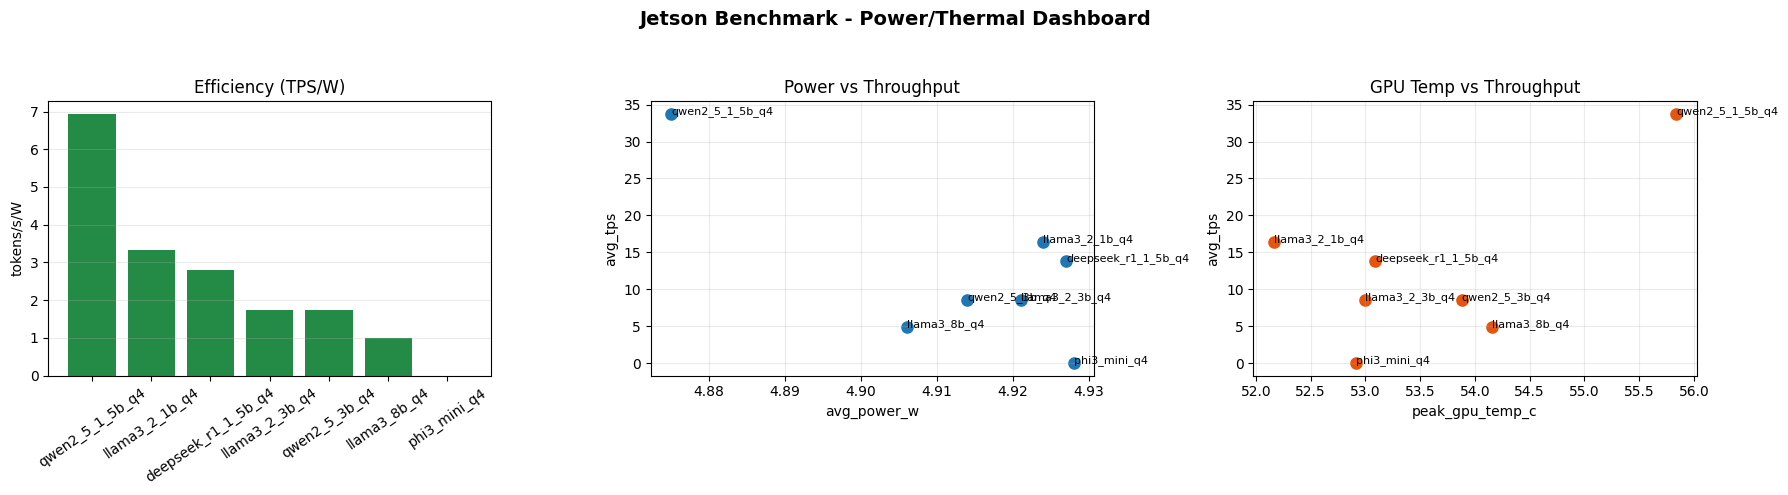

Saved dashboard:
- /home/jetson_orin_nano/llm/local_llm_bench/outputs/figures/benchmark_power_thermal_dashboard.png
- /home/jetson_orin_nano/llm/local_llm_bench/outputs/figures/benchmark_power_thermal_dashboard.svg


In [18]:
dash_df = df_ok.copy()

# Efficiency metric
dash_df["tps_per_w"] = np.where(
    (dash_df["avg_power_w"].notna()) & (dash_df["avg_power_w"] > 0),
    dash_df["avg_tps"] / dash_df["avg_power_w"],
    np.nan,
)

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Jetson Benchmark - Power/Thermal Dashboard", fontsize=14, fontweight="bold")

# (1) TPS per Watt bar
bar_df = dash_df.sort_values("tps_per_w", ascending=False)
axes2[0].bar(bar_df["name"], bar_df["tps_per_w"], color="#238b45")
axes2[0].set_title("Efficiency (TPS/W)")
axes2[0].set_ylabel("tokens/s/W")
axes2[0].tick_params(axis="x", rotation=35)
axes2[0].grid(axis="y", alpha=0.25)

# (2) Power vs TPS
axes2[1].scatter(dash_df["avg_power_w"], dash_df["avg_tps"], c="#1f78b4", s=65)
for _, r in dash_df.iterrows():
    if pd.notna(r.get("avg_power_w")) and pd.notna(r.get("avg_tps")):
        axes2[1].annotate(r["name"], (r["avg_power_w"], r["avg_tps"]), fontsize=8)
axes2[1].set_title("Power vs Throughput")
axes2[1].set_xlabel("avg_power_w")
axes2[1].set_ylabel("avg_tps")
axes2[1].grid(alpha=0.25)

# (3) GPU temp vs TPS
axes2[2].scatter(dash_df["peak_gpu_temp_c"], dash_df["avg_tps"], c="#e6550d", s=65)
for _, r in dash_df.iterrows():
    if pd.notna(r.get("peak_gpu_temp_c")) and pd.notna(r.get("avg_tps")):
        axes2[2].annotate(r["name"], (r["peak_gpu_temp_c"], r["avg_tps"]), fontsize=8)
axes2[2].set_title("GPU Temp vs Throughput")
axes2[2].set_xlabel("peak_gpu_temp_c")
axes2[2].set_ylabel("avg_tps")
axes2[2].grid(alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.94])
dash_png = FIG_DIR / "benchmark_power_thermal_dashboard.png"
dash_svg = FIG_DIR / "benchmark_power_thermal_dashboard.svg"
fig2.savefig(dash_png, dpi=180)
fig2.savefig(dash_svg)
plt.show()

print("Saved dashboard:")
print("-", dash_png)
print("-", dash_svg)

## 10) 실패 모델 정리 및 자동 제외 파라미터

실패 모델 목록을 별도로 저장하고, 분석 시 자동 제외/포함을 선택할 수 있는 파라미터를 제공합니다.

In [19]:
INCLUDE_FAILED_IN_ANALYSIS = False

failed_df = df_raw[df_raw["status"] != "ok"].copy() if "status" in df_raw.columns else pd.DataFrame()
failed_csv = OUTPUTS_DIR / "benchmark_failed_models.csv"

if not failed_df.empty:
    failed_df.to_csv(failed_csv, index=False)
    print(f"Saved failed model list: {failed_csv}")
    display_cols = [c for c in ["name", "path", "status", "error", "elapsed_wall_s"] if c in failed_df.columns]
    print("\nFailed rows:")
    display(failed_df[display_cols])
else:
    print("No failed models in current comparison_results.csv")

analysis_df = df_raw.copy() if INCLUDE_FAILED_IN_ANALYSIS else df_ok.copy()
print(f"\nAnalysis rows used: {len(analysis_df)} (INCLUDE_FAILED_IN_ANALYSIS={INCLUDE_FAILED_IN_ANALYSIS})")

Saved failed model list: /home/jetson_orin_nano/llm/local_llm_bench/outputs/benchmark_failed_models.csv

Failed rows:


,name,path,status,error,elapsed_wall_s
1,deepseek_r1_7b_q4,/home/jetson_orin_nano/llm/local_llm_bench/mod...,failed,benchmark.py exited with code 1,4.374
2,gemma2_2b_q4,/home/jetson_orin_nano/llm/local_llm_bench/mod...,failed,benchmark.py exited with code 1,15.458



Analysis rows used: 7 (INCLUDE_FAILED_IN_ANALYSIS=False)


## 11) 리포트용 단일 요약 이미지 생성

핵심 KPI(최고 TPS 모델, 최저 TTFT 모델, 메모리/전력 지표)를 한 장으로 정리한 리포트 카드를 생성합니다.

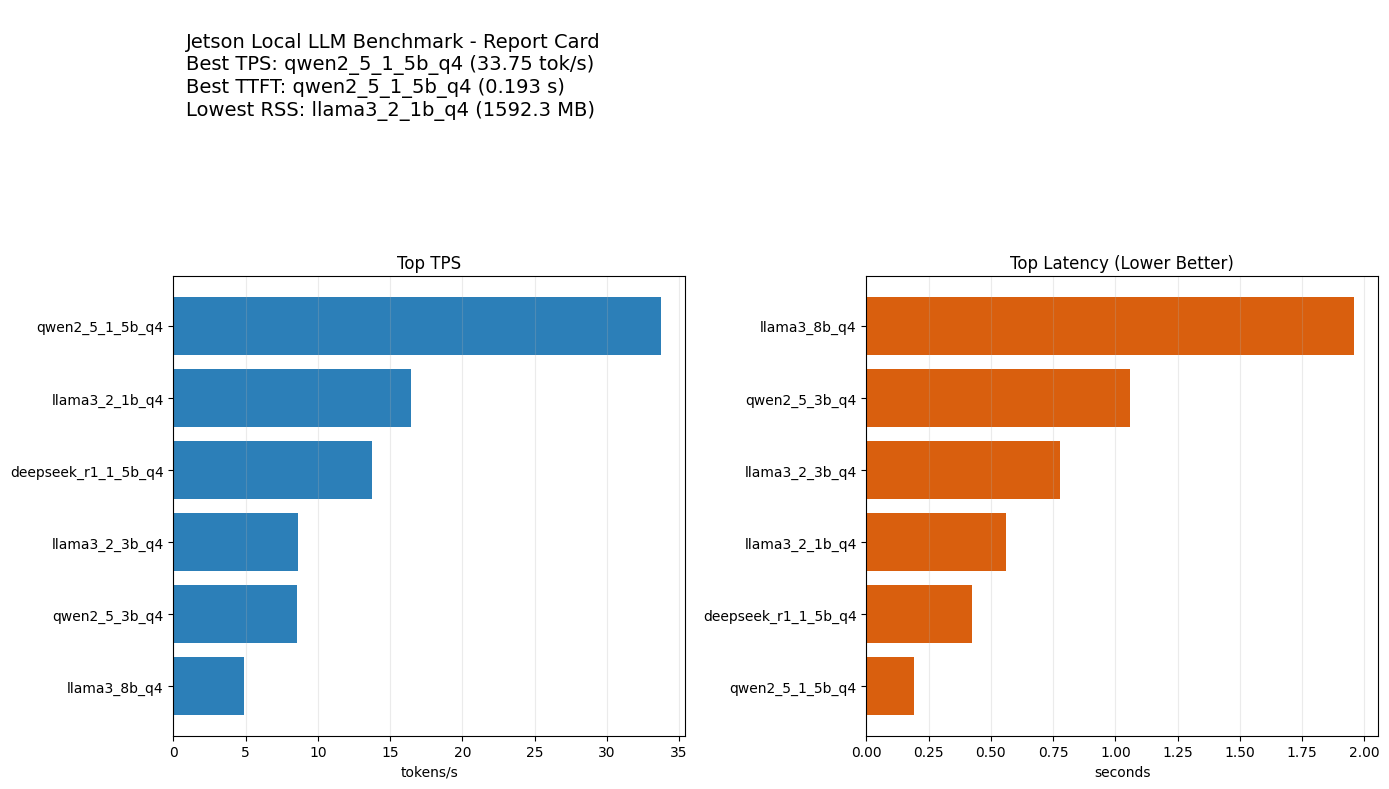

Saved report card:
- /home/jetson_orin_nano/llm/local_llm_bench/outputs/figures/benchmark_report_card.png
- /home/jetson_orin_nano/llm/local_llm_bench/outputs/figures/benchmark_report_card.svg


In [20]:
report_df = df_ok.sort_values("avg_tps", ascending=False).copy()

best_tps = report_df.iloc[0]
best_ttft = report_df.sort_values("avg_ttft_s", ascending=True).iloc[0]
lowest_rss = report_df.sort_values("peak_process_rss_mb", ascending=True).iloc[0]

fig3 = plt.figure(figsize=(14, 8))
gs = fig3.add_gridspec(2, 2, height_ratios=[1, 2])

# Header KPI text
ax_text = fig3.add_subplot(gs[0, :])
ax_text.axis("off")
header = [
    "Jetson Local LLM Benchmark - Report Card",
    f"Best TPS: {best_tps['name']} ({best_tps['avg_tps']:.2f} tok/s)",
    f"Best TTFT: {best_ttft['name']} ({best_ttft['avg_ttft_s']:.3f} s)",
    f"Lowest RSS: {lowest_rss['name']} ({lowest_rss['peak_process_rss_mb']:.1f} MB)",
]
ax_text.text(0.01, 0.9, "\n".join(header), fontsize=14, va="top")

# Throughput and latency mini charts
ax_tps = fig3.add_subplot(gs[1, 0])
ax_ttft = fig3.add_subplot(gs[1, 1])

show_df = report_df.head(6)
ax_tps.barh(show_df["name"][::-1], show_df["avg_tps"][::-1], color="#2c7fb8")
ax_tps.set_title("Top TPS")
ax_tps.set_xlabel("tokens/s")
ax_tps.grid(axis="x", alpha=0.25)

ax_ttft.barh(show_df.sort_values("avg_ttft_s")["name"], show_df.sort_values("avg_ttft_s")["avg_ttft_s"], color="#d95f0e")
ax_ttft.set_title("Top Latency (Lower Better)")
ax_ttft.set_xlabel("seconds")
ax_ttft.grid(axis="x", alpha=0.25)

plt.tight_layout()
report_png = FIG_DIR / "benchmark_report_card.png"
report_svg = FIG_DIR / "benchmark_report_card.svg"
fig3.savefig(report_png, dpi=180)
fig3.savefig(report_svg)
plt.show()

print("Saved report card:")
print("-", report_png)
print("-", report_svg)